<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L3_LSTMs_and_GRUs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=ArLRhvQ1usc) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P03.pdf)

In [1]:
# Week 7, Lecture 3: LSTM's and GRU's
from IPython.display import HTML, display

VIDEO_ID = "ArLRhvQ1usc"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 3: LSTMs and GRUs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.3 LSTMs and GRUs**.

**What you will learn**

- Why a plain RNN cannot hold information across a long gap.
- The **LSTM** cell in full: forget, input and output gates, the candidate content, and the cell state.
- The **constant error carousel**: set the forget gate to 1 and the input gate to 0, and the cell is preserved exactly.
- Why the additive cell update is a *gradient highway*, in contrast to the RNN's repeated matrix product.
- The **GRU**: two gates instead of three, no separate cell state, and 3/4 the parameters.
- Two convention traps that will bite you when comparing against PyTorch.

**Contents**

1. The long-term dependency problem
2. The LSTM cell, gate by gate
3. The constant error carousel
4. The gradient highway
5. The GRU
6. Parameter counts, and why GRUs are cheaper
7. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

The previous lecture showed that the gradient reaching back $n$ steps carries a product of
$n$ Jacobians, each of the form $\mathrm{diag}(1-h^2)W$. Since $\tanh' \le 1$, that product
shrinks geometrically and long-range dependencies stop contributing. The slides asked for
fixes that do not change the architecture — ReLU, better initialisation, regularisation,
shorter sequences. This lecture changes the architecture instead.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. The long-term dependency problem

Sometimes the useful context is close by: *"the clouds are in the ..."* needs only the last
few words. Sometimes it is far away: *"I grew up in France ... I speak fluent ..."* needs a
word from much earlier in the passage.

A plain RNN keeps everything in a single hidden vector that is rewritten at every step, so
old information is progressively morphed away. Let us measure how quickly.

In [3]:
# Push a signal into the state, then feed noise, and watch the signal disappear.
H, D = 8, 4
Wr = torch.randn(H, H) * 0.9
Ur = torch.randn(H, D) * 0.3

signal = torch.ones(H)                       # the thing we want to remember
h = signal.clone()
sims = []
for t in range(30):
    h = torch.tanh(Wr @ h + Ur @ torch.randn(D))
    sims.append(torch.nn.functional.cosine_similarity(h, signal, dim=0).item())

print('cosine similarity between the state and the original signal:')
for t in (0, 4, 9, 19, 29):
    print(f'  after {t + 1:2d} steps: {sims[t]:+.3f}')
print('\nthe state has forgotten what it started with')

cosine similarity between the state and the original signal:
  after  1 steps: +0.364
  after  5 steps: -0.039
  after 10 steps: +0.182
  after 20 steps: -0.049
  after 30 steps: -0.657

the state has forgotten what it started with


## 2. The LSTM cell, gate by gate

An LSTM keeps **two** things at each step: a hidden state $h_t$ and a **cell state** $C_t$.
The cell stores long-term information, and the LSTM can *erase*, *write* and *read* it —
controlled by three gates. Each gate is a sigmoid layer followed by an elementwise
multiply, so every gate value lies in $[0, 1]$: fully open, fully closed, or in between.

Writing $[h_{t-1}, x_t]$ for the concatenation of the previous hidden state and the current
input:

$$f_t = \sigma\left(W_f \cdot [h_{t-1}, x_t] + b_f\right) \qquad \text{forget: what is kept from the previous cell}$$
$$i_t = \sigma\left(W_i \cdot [h_{t-1}, x_t] + b_i\right) \qquad \text{input: what parts of the new content are written}$$
$$\tilde C_t = \tanh\left(W_C \cdot [h_{t-1}, x_t] + b_C\right) \qquad \text{the new content itself}$$
$$C_t = f_t * C_{t-1} + i_t * \tilde C_t \qquad \text{erase some, write some}$$
$$o_t = \sigma\left(W_o \cdot [h_{t-1}, x_t] + b_o\right) \qquad \text{output: what parts of the cell are read out}$$
$$h_t = o_t * \tanh(C_t)$$

Note where each nonlinearity goes: **sigmoid on the three gates, tanh on the candidate
content, and tanh again on the cell when reading it out**.

In [4]:
# The LSTM cell, written exactly as the equations above.
class LSTMFromScratch:
    def __init__(self, D, H, seed=0):
        g = torch.Generator().manual_seed(seed)
        k = (H + D)
        mk = lambda: (torch.randn(H, k, generator=g) * 0.3).requires_grad_(True)
        self.Wf, self.Wi, self.WC, self.Wo = mk(), mk(), mk(), mk()
        self.bf = torch.zeros(H, requires_grad=True)
        self.bi = torch.zeros(H, requires_grad=True)
        self.bC = torch.zeros(H, requires_grad=True)
        self.bo = torch.zeros(H, requires_grad=True)
        self.H = H

    def step(self, x, h, C):
        z = torch.cat([h, x])                        # [h_{t-1}, x_t]
        f = torch.sigmoid(self.Wf @ z + self.bf)
        i = torch.sigmoid(self.Wi @ z + self.bi)
        Ct_tilde = torch.tanh(self.WC @ z + self.bC)
        C = f * C + i * Ct_tilde                     # erase some, write some
        o = torch.sigmoid(self.Wo @ z + self.bo)
        h = o * torch.tanh(C)
        return h, C, dict(f=f, i=i, o=o, C_tilde=Ct_tilde)

cell = LSTMFromScratch(D, H)
h, C = torch.zeros(H), torch.zeros(H)
h, C, gates = cell.step(torch.randn(D), h, C)

for name, v in gates.items():
    lo, hi = v.min().item(), v.max().item()
    print(f'  {name:8s} range [{lo:+.3f}, {hi:+.3f}]')
print('\nthe three gates lie in [0, 1]; the candidate content lies in [-1, 1]')

  f        range [+0.387, +0.650]
  i        range [+0.394, +0.637]
  o        range [+0.444, +0.617]
  C_tilde  range [-0.575, +0.158]

the three gates lie in [0, 1]; the candidate content lies in [-1, 1]


## 3. The constant error carousel

The slides ask: *what can you tell about the cell state if the forget gate is set to 1 and
the input gate to 0?* From

$$C_t = f_t * C_{t-1} + i_t * \tilde C_t$$

setting $f_t = 1$ and $i_t = 0$ gives $C_t = C_{t-1}$ exactly. The information is
**preserved indefinitely**. That is the mechanism the whole architecture is built around.

In [5]:
# Force the gates and check the cell is preserved bit for bit over many steps.
C0 = torch.randn(H)
C = C0.clone()
for t in range(1000):
    f = torch.ones(H)                        # forget gate fully open
    i = torch.zeros(H)                       # input gate fully closed
    C_tilde = torch.randn(H)                 # whatever the candidate says, it is ignored
    C = f * C + i * C_tilde

assert torch.equal(C, C0), 'the cell state changed despite f=1, i=0'
print(f'after 1000 steps with f=1, i=0:  max |C_t - C_0| = {(C - C0).abs().max():.1e}')
print('information is preserved indefinitely, exactly as the slides claim')

# And the degenerate case the slides also ask about: i=1, f=0, o=1 gives "almost" a plain RNN.
print('\nwith i=1, f=0, o=1:  C_t = C_tilde  and  h_t = tanh(C_t) = tanh(tanh(...))')
print('almost a vanilla RNN, but with an extra tanh applied - the deck\'s "why almost?"')

after 1000 steps with f=1, i=0:  max |C_t - C_0| = 0.0e+00
information is preserved indefinitely, exactly as the slides claim

with i=1, f=0, o=1:  C_t = C_tilde  and  h_t = tanh(C_t) = tanh(tanh(...))
almost a vanilla RNN, but with an extra tanh applied - the deck's "why almost?"


## 4. The gradient highway

In a plain RNN the gradient from step $t$ to step $t-1$ is multiplied by
$\mathrm{diag}(1-h^2)W$ — the *same* matrix $W$ every step, so the product is a matrix power
and decays geometrically.

In an LSTM the cell state path is **additive**, and

$$\frac{\partial C_t}{\partial C_{t-1}} = f_t$$

elementwise. There is no repeated weight matrix on this path. The slides ask why the forget
gate does not spoil the argument: because it reduces the gradient *where it should* — it is
part of the design, not an accident of the algebra.

In [6]:
# Compare how far the gradient reaches: plain RNN vs the LSTM cell path.
def rnn_reach(T=60, scale=0.9, seed=0):
    torch.manual_seed(seed)
    Wl = torch.randn(H, H) * scale
    h = torch.randn(H, requires_grad=True)
    states = [h]
    for _ in range(T):
        states.append(torch.tanh(Wl @ states[-1]))
    g = torch.autograd.grad(states[-1].sum(), h)[0]
    return g.norm().item()

def lstm_reach(T=60, forget=0.95, seed=0):
    torch.manual_seed(seed)
    C = torch.randn(H, requires_grad=True)
    cur = C
    for _ in range(T):
        f = torch.full((H,), forget)
        cur = f * cur + torch.zeros(H)       # the additive highway, input gate closed
    g = torch.autograd.grad(cur.sum(), C)[0]
    return g.norm().item()

print(f'{"steps":>6s} {"plain RNN":>14s} {"LSTM cell path":>16s}')
for T in (10, 20, 40, 60):
    print(f'{T:6d} {rnn_reach(T):14.3e} {lstm_reach(T):16.3e}')
print('\nthe RNN path decays geometrically; the cell path decays only as fast as the forget gate')

 steps      plain RNN   LSTM cell path
    10      1.690e+01        1.693e+00
    20      4.078e+00        1.014e+00
    40      1.101e+01        3.635e-01
    60      2.617e+01        1.303e-01

the RNN path decays geometrically; the cell path decays only as fast as the forget gate


## 5. The GRU

The GRU (2014) is a simpler alternative. It **combines the forget and input gates into one
update gate**, and **merges the cell state into the hidden state**, so there is no separate
$C_t$ and no output gate:

$$z_t = \sigma\left(W_z \cdot [h_{t-1}, x_t]\right) \qquad \text{update: what is preserved vs updated}$$
$$r_t = \sigma\left(W_r \cdot [h_{t-1}, x_t]\right) \qquad \text{reset: which parts of the old state are used}$$
$$\tilde h_t = \tanh\left(W \cdot [r_t * h_{t-1},\, x_t]\right)$$
$$h_t = (1 - z_t) * h_{t-1} + z_t * \tilde h_t$$

Note the deck writes the GRU equations **without bias terms**, while its LSTM equations have
them. That is a figure-source artifact rather than a modelling decision.

In [7]:
# The GRU cell, exactly as the deck writes it.
class GRUFromScratch:
    def __init__(self, D, H, seed=0):
        g = torch.Generator().manual_seed(seed)
        mk = lambda: (torch.randn(H, H + D, generator=g) * 0.3).requires_grad_(True)
        self.Wz, self.Wr, self.W = mk(), mk(), mk()
        self.H = H

    def step(self, x, h):
        z = torch.sigmoid(self.Wz @ torch.cat([h, x]))
        r = torch.sigmoid(self.Wr @ torch.cat([h, x]))
        h_tilde = torch.tanh(self.W @ torch.cat([r * h, x]))   # r applied BEFORE the matmul
        h_new = (1 - z) * h + z * h_tilde
        return h_new, dict(z=z, r=r, h_tilde=h_tilde)

gru = GRUFromScratch(D, H)
h = torch.zeros(H)
h, g = gru.step(torch.randn(D), h)
print(f'  update gate z range [{g["z"].min():+.3f}, {g["z"].max():+.3f}]')
print(f'  reset  gate r range [{g["r"].min():+.3f}, {g["r"].max():+.3f}]')

# What the slides ask: reset all 1s, update all 0s.
h_prev = torch.randn(H)
z0, r1 = torch.zeros(H), torch.ones(H)
h_frozen = (1 - z0) * h_prev + z0 * torch.randn(H)
assert torch.equal(h_frozen, h_prev)
print('\nwith update gate z = 0 the state is frozen: h_t = h_{t-1}, whatever the input')

  update gate z range [+0.446, +0.592]
  reset  gate r range [+0.436, +0.603]

with update gate z = 0 the state is frozen: h_t = h_{t-1}, whatever the input


## 6. Parameter counts, and why GRUs are cheaper

With input size $D$ and hidden size $H$, the concatenation $[h_{t-1}, x_t]$ has length
$H + D$, so each weight matrix is $H \times (H+D)$ and each bias has $H$ entries. Counting
the blocks:

| Cell | Blocks | Parameters |
|---|---|---|
| vanilla RNN | 1 | $H(H+D+1)$ |
| **GRU** | 3 ($z, r, \tilde h$) | $3H(H+D+1)$ |
| **LSTM** | 4 ($f, i, \tilde C, o$) | $4H(H+D+1)$ |

So a GRU costs **three quarters** of an LSTM. That is the quantitative content of the
slides' remark that a GRU has "lesser parameters to learn".

In [8]:
# Verify the counts against PyTorch's own modules.
D_, H_ = 10, 20
formula = {'RNN': 1 * H_ * (H_ + D_ + 1),
           'GRU': 3 * H_ * (H_ + D_ + 1),
           'LSTM': 4 * H_ * (H_ + D_ + 1)}

# PyTorch splits each block into W_ih and W_hh with a bias on each, so it has one extra
# bias vector per block compared with the deck's single-bias concatenation form.
actual = {}
for name, mod in [('RNN', nn.RNNCell(D_, H_)), ('GRU', nn.GRUCell(D_, H_)), ('LSTM', nn.LSTMCell(D_, H_))]:
    actual[name] = sum(p.numel() for p in mod.parameters())

print(f'{"cell":6s} {"deck formula":>14s} {"PyTorch":>10s} {"difference":>12s}')
for name in ('RNN', 'GRU', 'LSTM'):
    blocks = {'RNN': 1, 'GRU': 3, 'LSTM': 4}[name]
    print(f'{name:6s} {formula[name]:14d} {actual[name]:10d} {actual[name] - formula[name]:12d}'
          f'   (= {blocks} extra bias vectors of size {H_})')
    assert actual[name] - formula[name] == blocks * H_

ratio = formula['GRU'] / formula['LSTM']
assert abs(ratio - 0.75) < 1e-9
print(f'\nGRU : LSTM parameter ratio = {ratio:.2f}  (exactly 3/4)')

cell     deck formula    PyTorch   difference
RNN               620        640           20   (= 1 extra bias vectors of size 20)
GRU              1860       1920           60   (= 3 extra bias vectors of size 20)
LSTM             2480       2560           80   (= 4 extra bias vectors of size 20)

GRU : LSTM parameter ratio = 0.75  (exactly 3/4)


## 7. Explore and verify

Two things are worth checking against PyTorch, and both contain a trap. Our from-scratch
LSTM should match `nn.LSTMCell` exactly once the weights are mapped across. The GRU will
**not** match `nn.GRUCell`, for two separate reasons — and finding out why is more
instructive than getting a match.

In [9]:
# 1. Our LSTM == nn.LSTMCell, once the weights are mapped.
# PyTorch stores weight_ih (4H x D) and weight_hh (4H x H) in gate order i, f, g, o.
# Our matrices are (H x (H+D)) applied to [h, x], so column block :H is the h part.
torch.manual_seed(0)
c = LSTMFromScratch(D, H, seed=1)
ref = nn.LSTMCell(D, H)

with torch.no_grad():
    order = [c.Wi, c.Wf, c.WC, c.Wo]                 # PyTorch order: i, f, g(=C_tilde), o
    ref.weight_hh.copy_(torch.cat([M[:, :H] for M in order]))
    ref.weight_ih.copy_(torch.cat([M[:, H:] for M in order]))
    ref.bias_ih.copy_(torch.cat([c.bi, c.bf, c.bC, c.bo]))
    ref.bias_hh.zero_()

x, h0, C0 = torch.randn(D), torch.randn(H), torch.randn(H)
ours_h, ours_C, _ = c.step(x, h0, C0)
ref_h, ref_C = ref(x[None], (h0[None], C0[None]))

assert torch.allclose(ours_h, ref_h[0], atol=1e-5), 'hidden state disagrees'
assert torch.allclose(ours_C, ref_C[0], atol=1e-5), 'cell state disagrees'
print(f'LSTM: ours vs nn.LSTMCell, max |difference| = {(ours_h - ref_h[0]).abs().max():.2e}')

LSTM: ours vs nn.LSTMCell, max |difference| = 5.22e-08


In [10]:
# 2. The GRU does NOT match, and there are two separate reasons.
gr = GRUFromScratch(D, H, seed=1)
ref_gru = nn.GRUCell(D, H, bias=False)

with torch.no_grad():
    order = [gr.Wr, gr.Wz, gr.W]                     # PyTorch order: r, z, n
    ref_gru.weight_hh.copy_(torch.cat([M[:, :H] for M in order]))
    ref_gru.weight_ih.copy_(torch.cat([M[:, H:] for M in order]))

x, h0 = torch.randn(D), torch.randn(H)
ours, parts = gr.step(x, h0)
theirs = ref_gru(x[None], h0[None])[0]

print(f'ours   {ours[:4].tolist()}')
print(f'theirs {theirs[:4].tolist()}')
print(f'max |difference| = {(ours - theirs).abs().max():.4f}   -> they disagree\n')

print('Reason 1: the update gate has the opposite meaning.')
print('  deck    : h_t = (1 - z) * h_{t-1} + z * h_tilde')
print('  PyTorch : h_t = (1 - z) * n       + z * h_{t-1}')
print('  so z = 0 freezes the state in the deck, but REPLACES it in PyTorch.\n')

print('Reason 2: where the reset gate is applied.')
print('  deck    : h_tilde = tanh(W . [r * h, x])   -> r applied BEFORE the matmul')
print('  PyTorch : n       = tanh(W_in x + r * (W_hn h))  -> r applied AFTER')
z_ = parts['z']
swapped = z_ * h0 + (1 - z_) * parts['h_tilde']
print(f'\nswapping z for (1-z) alone still does not match: max |diff| = '
      f'{(swapped - theirs).abs().max():.4f}  (reason 2 remains)')

ours   [0.4225631654262543, -0.7738617062568665, 0.8700975775718689, 1.4700825214385986]
theirs [0.46541956067085266, -1.3651096820831299, 0.7389236688613892, 2.754789113998413]
max |difference| = 1.2847   -> they disagree

Reason 1: the update gate has the opposite meaning.
  deck    : h_t = (1 - z) * h_{t-1} + z * h_tilde
  PyTorch : h_t = (1 - z) * n       + z * h_{t-1}
  so z = 0 freezes the state in the deck, but REPLACES it in PyTorch.

Reason 2: where the reset gate is applied.
  deck    : h_tilde = tanh(W . [r * h, x])   -> r applied BEFORE the matmul
  PyTorch : n       = tanh(W_in x + r * (W_hn h))  -> r applied AFTER

swapping z for (1-z) alone still does not match: max |diff| = 0.1934  (reason 2 remains)


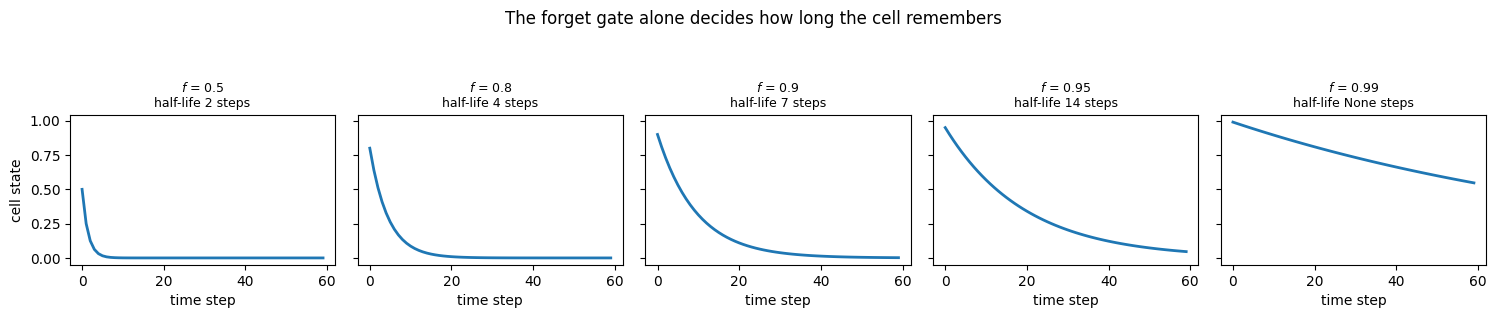

In [11]:
# Static sweep: the forget gate sets the half-life of the cell state.
fig, ax = plt.subplots(1, 5, figsize=(15, 2.9), sharey=True)
for a, f_val in zip(ax, [0.5, 0.8, 0.9, 0.95, 0.99]):
    C = torch.ones(1)
    trace = []
    for _ in range(60):
        C = f_val * C
        trace.append(C.item())
    half = next((i + 1 for i, v in enumerate(trace) if v < 0.5), None)
    a.plot(trace, lw=2)
    a.set_title(f'$f$ = {f_val}\nhalf-life {half} steps', fontsize=9)
    a.set_xlabel('time step')
ax[0].set_ylabel('cell state')
fig.suptitle('The forget gate alone decides how long the cell remembers', y=1.08)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [12]:
# Live: compare the LSTM cell path against a plain RNN path at the same depth.
from ipywidgets import interact, FloatSlider, IntSlider

def compare(forget=0.95, rnn_scale=0.9, steps=60):
    lstm_trace, rnn_trace = [], []
    C, hn = 1.0, 1.0
    torch.manual_seed(0)
    Wl = torch.randn(H, H) * rnn_scale
    hv = torch.ones(H)
    for _ in range(steps):
        C *= forget
        lstm_trace.append(C)
        hv = torch.tanh(Wl @ hv)
        rnn_trace.append(hv.norm().item() / np.sqrt(H))
    fig, a = plt.subplots(figsize=(7.5, 3.4))
    a.semilogy(lstm_trace, lw=2, label=f'LSTM cell path (f={forget})')
    a.semilogy(rnn_trace, lw=2, label=f'plain RNN (|W| scale {rnn_scale})')
    a.set_xlabel('time step'); a.set_ylabel('signal retained'); a.legend()
    plt.tight_layout(); plt.show()

interact(compare, forget=FloatSlider(min=0.5, max=0.999, step=0.01, value=0.95),
                  rnn_scale=FloatSlider(min=0.3, max=1.5, step=0.1, value=0.9),
                  steps=IntSlider(min=20, max=120, step=20, value=60));

interactive(children=(FloatSlider(value=0.95, description='forget', max=0.999, min=0.5, step=0.01), FloatSlide…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Two states** | An LSTM carries a hidden state $h_t$ **and** a cell state $C_t$ |
| **Three gates** | Forget (what to keep), input (what to write), output (what to read); all sigmoid, all in $[0,1]$ |
| **Cell update** | $C_t = f_t * C_{t-1} + i_t * \tilde C_t$ — erase some, write some |
| **Constant error carousel** | $f=1, i=0 \Rightarrow C_t = C_{t-1}$ exactly; information is preserved indefinitely |
| **Gradient highway** | $\partial C_t / \partial C_{t-1} = f_t$, with no repeated weight matrix on the path |
| **GRU** | Update and reset gates only; cell merged into the hidden state; no output gate |
| **Cost** | GRU has 3 blocks to the LSTM's 4, so exactly **3/4** the parameters |
| **Default choice** | LSTM is a good default, especially with long-range dependencies or lots of data; GRU for speed |

## Exercises

1. **How does a GRU address vanishing gradients?** (The slides set this as homework.) Derive $\partial h_t / \partial h_{t-1}$ for the GRU and identify the term that plays the role of the LSTM's forget gate.
2. **Peephole connections.** Gers and Schmidhuber (2000) let the gates see the cell state, concatenating $C_{t-1}$ into $f$ and $i$, and $C_t$ into $o$. Implement it and work out how many parameters it adds.
3. **Coupled gates.** The variant $C_t = f_t * C_{t-1} + (1 - f_t) * \tilde C_t$ decides what to forget and what to add together. Implement it, count its parameters, and show the count now matches a GRU.
4. **Both conventions.** Section 7 showed the deck's GRU and PyTorch's disagree for two reasons. Fix *both* and get an exact match with `nn.GRUCell` — reverse the update gate, and move the reset gate to after the matmul.
